# AG-HYPOPT · Trial 01

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

The campaign opens with an empty registry (`trials.json` trials = []), so there is no previous trial to
recall: this is the first of a fresh MAX_TRIALS=30 run, restarted after a generator bug (now fixed)
stopped the earlier attempt after a single trial. Frozen for every trial: the exp5 schedule
(`lr_mu 0.1669`, `mu_anneal 0.3455`, `lr_gamma 0.4716`, `gamma_anneal 0.4723`), the exp7 bandwidth
(rule `target`, `h_f 4.0`, `h_s 3.6745`), and the exp6 gamma trust region (`gamma_rel_cap 0.10736`).
Only two knobs move: `loss_family` and `sigma_weight`.

The reference point for the whole campaign is the KDE control, which reproduces exp6's headline
objective **0.080328**; the success bar is objective < ~0.086, with any family that beats the KDE
control being a genuine find. The physics brief (context.md sections 0, 5, 7) explains why the loss
might matter at all: the residual error is concentrated in the low-count (T05/T20) mu-gamma cells
(FM#8), where the simulator's sigma_fit channel is structurally 1.04-4.25x too narrow and grows worse
with T. The KDE NLL leans on that mis-scaled sigma channel; the bandwidth-free / robust families
(W1, energy, MMD) were pre-authorized as the candidate attack on the same wall, all scale-normalized
so the comparison is about the loss *form*, not its scale.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_01'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = uniform  (0/5 trials)
ID |     ei | params
 1 |      - | {"loss_family": "energy_2d", "sigma_weight": 0.9504636963259353}
 2 |      - | {"loss_family": "mmd_2d", "sigma_weight": 0.14415961271963373}
 3 |      - | {"loss_family": "w1_fwhm", "sigma_weight": 0.31183145201048545}
 4 |      - | {"loss_family": "cvm_fwhm", "sigma_weight": 0.42332644897257565}
 5 |      - | {"loss_family": "w1_2d", "sigma_weight": 0.4091991363691613}
 6 |      - | {"loss_family": "w1_fwhm", "sigma_weight": 0.5495936876730595}
 7 |      - | {"loss_family": "kde", "sigma_weight": 0.7535131086748066}
 8 |      - | {"loss_family": "kde", "sigma_weight": 0.5381433132192782}
 9 |      - | {"loss_family": "w1_fwhm", "sigma_weight": 0.7884287034284043}
10 |      - | {"loss_family": "w1_2d", "sigma_weight": 0.303194829291645}


## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

With an empty registry this first trial is pure initialization: the phase is `uniform` (0/5 trials), so
the candidates are near-random draws spanning all six families and a wide spread of `sigma_weight`.
There is no prior result to exploit, so the sensible criterion is coverage plus representativeness:
pick a family that is a genuine *alternative* to the KDE control (not a FWHM-only control) and a
`sigma_weight` near the middle of the range so the sigma channel is neither ignored nor dominant.

Scanning the table: candidates 1 (energy_2d, sw 0.95) and 3/6/9 (w1_fwhm) are less informative first
- the first pins sigma at ~1.0, the w1_fwhm ones drop the sigma link entirely (they are controls for
the mu-channel question, better used once a 2-D family has produced a baseline). Candidate 2 (mmd_2d,
sw 0.144) almost removes the sigma channel while 4 (cvm_fwhm) is again FWHM-only. Candidates 5 and 10
are the two `w1_2d` draws, the flagship bandwidth-free 2-D alternative that keeps both channels.
Candidate 5 has the more central `sigma_weight` (0.409 vs 0.303), matching the balanced-sigma-link
character of the KDE control and giving the cleanest first read on whether the W1 loss *form* shifts
the optimizer. It is also the family whose mu-reward runaway the fixed per-step rescaling was
targeted at, so it doubles as a check that the fix works.

I choose candidate 5.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 5              # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'loss_family': 'w1_2d', 'sigma_weight': 0.4091991363691613}
Running  1nW Trans05 ... 

μ 9.39 -> 5.97 | γ 8.5 -> 3.31 | NLL 25.37


Running  1nW Trans20 ... 

μ 17.32 -> 28.72 | γ 8.5 -> 5.85 | NLL 4.51


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 63.55 | γ 14.1 -> 14.37 | NLL 2.17


Running 3nW Trans100 ... 

μ 175.71 -> 98.52 | γ 14.1 -> 13.87 | NLL 2.21



Total: 7.4 min


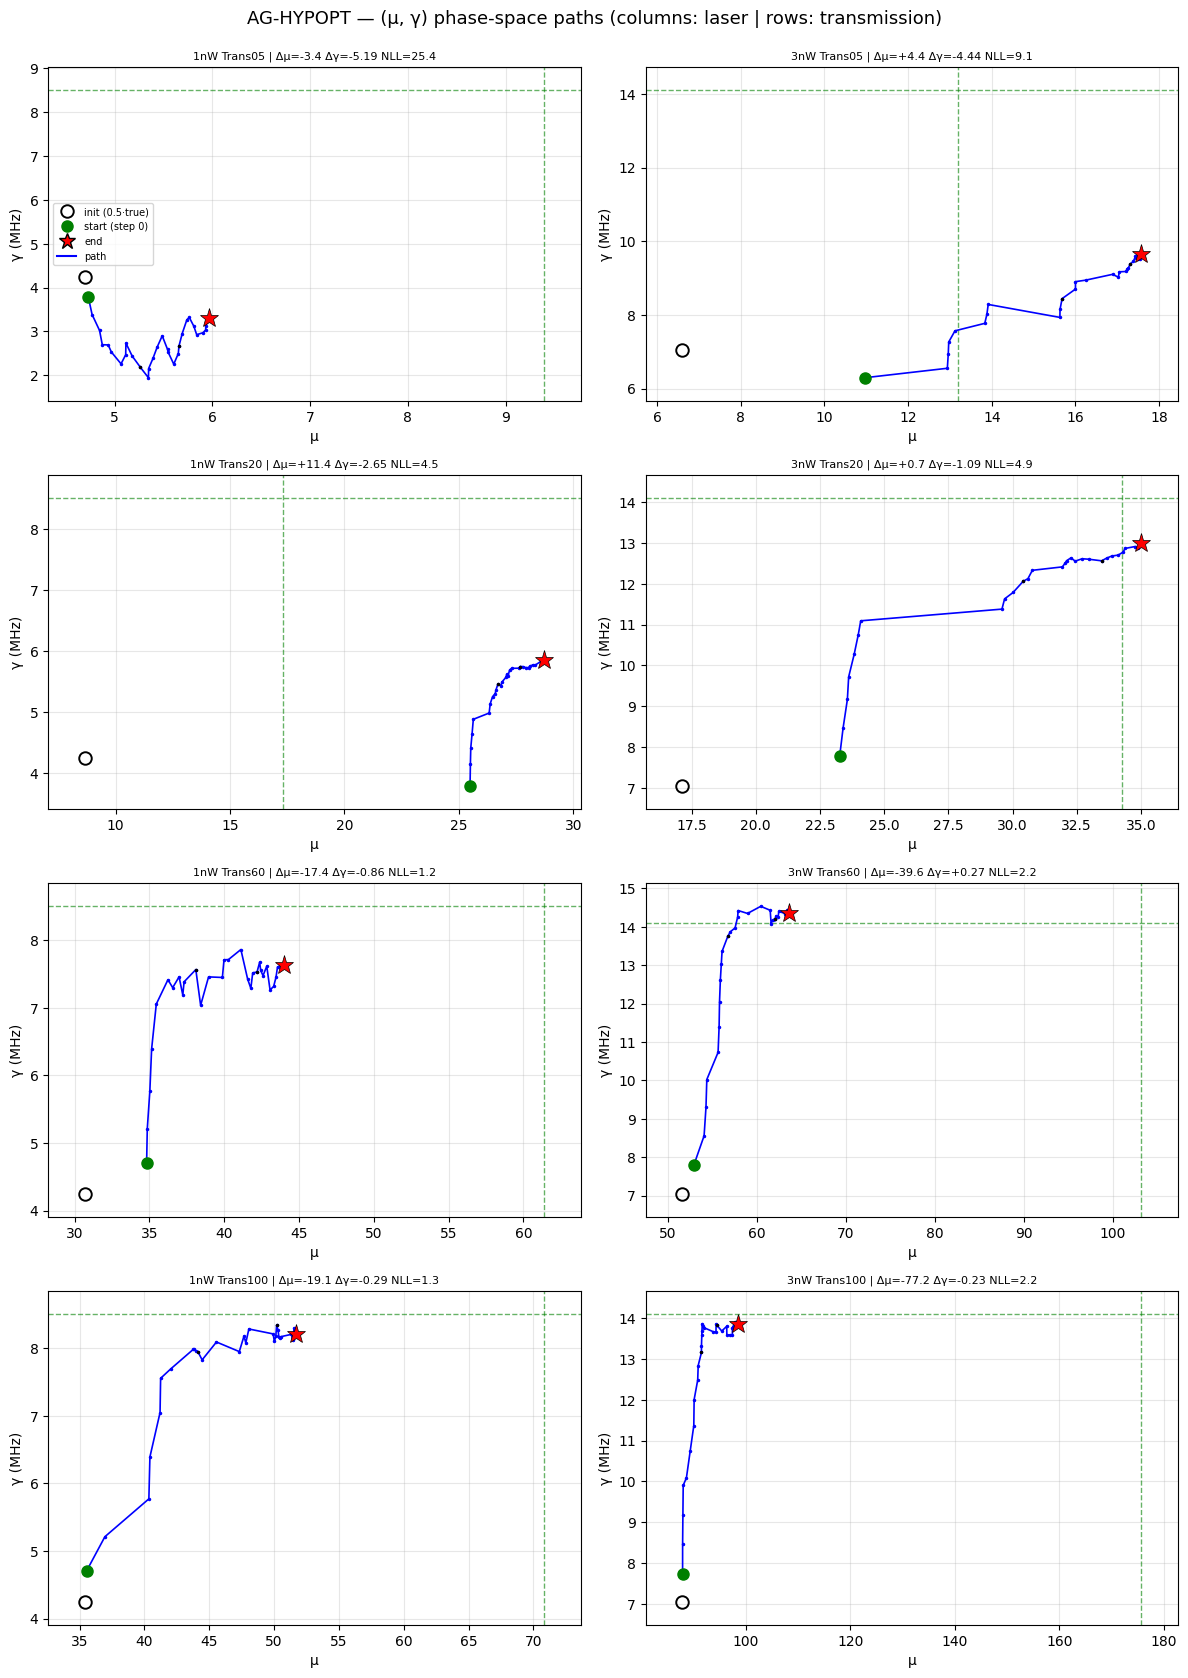

trial finished in 7.4 min
objective = 0.0895 ± 0.0325
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    5.97   -36.5 |     8.50    3.31   -61.0
1nW Trans20       17.32   28.72   +65.9 |     8.50    5.85   -31.2
1nW Trans60       61.37   43.97   -28.4 |     8.50    7.64   -10.2
1nW Trans100       70.82   51.70   -27.0 |     8.50    8.21    -3.4
3nW Trans05       13.20   17.58   +33.1 |    14.10    9.66   -31.5
3nW Trans20       34.28   35.02    +2.2 |    14.10   13.01    -7.7
3nW Trans60      103.20   63.55   -38.4 |    14.10   14.37    +1.9
3nW Trans100      175.71   98.52   -43.9 |    14.10   13.87    -1.7

weighted objective (T-graded, cap=1.0) = 0.0895 | diverged cells: 0
μ: RMSE 32.325 (rel 38.3%, bias -17.533) | γ: RMSE 2.639 (rel 27.1%, bias -1.809)


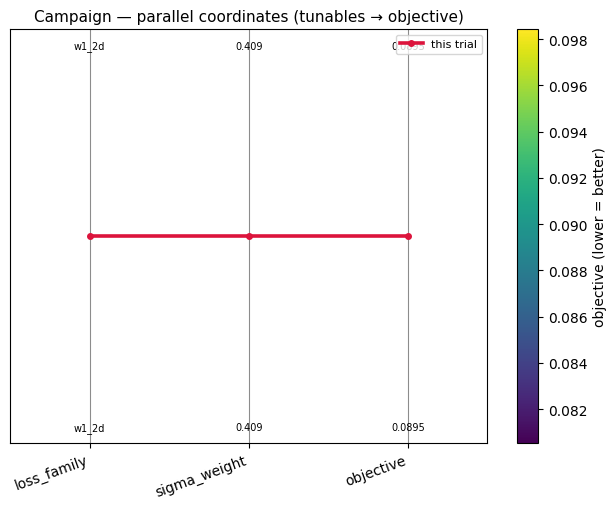

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

**Facts.** Chosen config `{loss_family: 'w1_2d', sigma_weight: 0.4092}` (candidate 5). Trial time
7.4 min, objective **0.0895 +/- 0.0325**, **0 diverged cells** (all mu inside (0.2, 1500), all gamma
finite and inside (0.02, 500)). Reference: the KDE control reproduces **0.080328**, so this first
alternative-loss trial lands ~0.009 *worse* than the control and does **not** clear the ~0.086 bar.

**Per-cell behaviour.** Every cell ran to a finite (mu, gamma) with no blow-up, and the error is not
uniform:

- 1nW Trans05: mu 9.39 -> 5.97 (-36.5 %), gamma 8.5 -> 3.31 (-61.0 %) - the worst cell, a collapse of
  both channels in the lowest-count experiment.
- 1nW Trans20: mu 17.32 -> 28.72 (**+65.9 %**, the only large mu *overshoot*), gamma -31.2 %.
- 1nW Trans60 / Trans100: mu -28.4 % / -27.0 %, gamma -10.2 % / -3.4 %.
- 3nW Trans05 / Trans20: mu +33.1 % / +2.2 %, gamma -31.5 % / -7.7 %.
- 3nW Trans60 / Trans100: mu -38.4 % / -43.9 %, gamma +1.9 % / -1.7 % - gamma essentially right at
  high T, mu badly low.

**Aggregates.** mu RMSE 32.33 (rel 38.3 %), bias -17.53 (systematically low, driven by the high-T
cells); gamma RMSE 2.64 (rel 27.1 %), bias -1.81. So gamma is recovered decently (good at high T, weak
in the low-count cells) while mu carries the objective.

**Process check.** The fixed per-step mu-reward rescaling did its job: the previous w1_2d mu-runaway
(~1120 on 1nW T05) is gone and the largest mu anywhere is 98.5. With one trial there is no trend yet,
but the family already sits on the wrong side of the control, and the damage is in the low-count mu
channel (T05/T20) - exactly the FM#8 locus this campaign targets.

**Summary:** First alternative-loss trial (w1_2d, sigma_weight 0.409) reaches objective 0.0895, about
0.009 worse than the KDE control (0.0803), with no divergences and the error concentrated in the
low-count mu channel.
**Key insight:** The bandwidth-free W1 loss is fully stable (no mu runaway, no gamma divergence) but
currently recovers low-count mu worse than the KDE control, so it has not yet earned its keep.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: none - this is a loss-FORM comparison inside the pre-authorized knob.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'w1_2d (sigma_weight 0.4092) reaches objective 0.0895, about 0.009 worse than the KDE control 0.0803, with no divergences and error concentrated in the low-count mu channel.'      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = 'The bandwidth-free W1 loss is fully stable (no mu runaway, gamma finite) but recovers low-count mu worse than the KDE control, so it has not yet earned its keep.'  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_01 | current best: trial_01


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_02.ipynb. Open it and follow its cells from the top.
